# Титульный лист

**Министерство науки и высшего образования РФ**  
**Лабораторная работа №5**  
**Дисциплина:** Технологии машинного обучения  
**Тема:** Ансамбли моделей машинного обучения. Часть 1

**Студент:** Яншин Т.И.
**Группа:** ИУ5-66Б 

# Описание задания

Цель лабораторной работы: изучение ансамблей моделей машинного обучения.

Задание:
1. Выбрать датасет для задачи классификации или регрессии.
2. При необходимости обработать пропуски и категориальные признаки.
3. Разделить выборку на обучающую и тестовую (`train_test_split`).
4. Обучить ансамблевые модели:
   - две модели группы бэггинга;
   - AdaBoost;
   - градиентный бустинг.
5. Оценить качество моделей с помощью метрики и сравнить результаты.

In [ ]:
# 1. Импорт библиотек и базовая настройка
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

RANDOM_STATE = 42
TEST_SIZE = 0.25

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

project_dir = Path.cwd()
artifacts_dir = project_dir / "artifacts" / "lab5"
artifacts_dir.mkdir(parents=True, exist_ok=True)

print("Рабочая директория:", project_dir)
print("Папка артефактов:", artifacts_dir)

Рабочая директория: D:\6 сем\тмо\lab5
Папка артефактов: D:\6 сем\тмо\lab5\artifacts\lab5


In [ ]:
# 2. Загрузка и подготовка датасета
# Используем Iris (не относится к медицинским датасетам по раку).
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df = df.rename(columns={"target": "label"})

# Добавим категориальный признак из численного,
# чтобы продемонстрировать кодирование категорий.
df["petal_length_level"] = pd.cut(
    df["petal length (cm)"],
    bins=[-np.inf, 2.5, 5.0, np.inf],
    labels=["short", "medium", "long"],
)

# Добавим небольшое число пропусков для демонстрации импутации.
rng = np.random.default_rng(RANDOM_STATE)
missing_idx_1 = rng.choice(df.index, size=8, replace=False)
missing_idx_2 = rng.choice(df.index, size=6, replace=False)

df.loc[missing_idx_1, "sepal length (cm)"] = np.nan
df.loc[missing_idx_2, "petal_length_level"] = np.nan

print("Размер датасета:", df.shape)
print("Тип задачи: классификация")
print("Целевая переменная: label")
print("Пропуски по столбцам:")
print(df.isna().sum())

display(df.head())

Размер датасета: (150, 6)
Тип задачи: классификация
Целевая переменная: label
Пропуски по столбцам:
sepal length (cm)     8
sepal width (cm)      0
petal length (cm)     0
petal width (cm)      0
label                 0
petal_length_level    6
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label,petal_length_level
0,5.1,3.5,1.4,0.2,0,short
1,4.9,3.0,1.4,0.2,0,short
2,4.7,3.2,1.3,0.2,0,short
3,4.6,3.1,1.5,0.2,0,short
4,5.0,3.6,1.4,0.2,0,short


In [ ]:
# 3. Разделение на train/test
X = df.drop(columns=["label"])
y = df["label"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Размер X_train: (112, 5)
Размер X_test: (38, 5)
Числовые признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Категориальные признаки: ['petal_length_level']


In [ ]:
# 4. Препроцессинг: импутация + кодирование категориальных признаков
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [ ]:
# 5. Обучение ансамблевых моделей
models = {
    "BaggingClassifier": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "AdaBoostClassifier": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.8,
        random_state=RANDOM_STATE,
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")

    results.append(
        {
            "model": model_name,
            "accuracy": acc,
            "f1_weighted": f1w,
        }
    )
    trained_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(by="f1_weighted", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,f1_weighted
0,GradientBoostingClassifier,0.921053,0.921943
1,RandomForestClassifier,0.921053,0.920936
2,AdaBoostClassifier,0.894737,0.896345
3,BaggingClassifier,0.894737,0.894110


In [ ]:
# 6. Детальная метрика для лучшей модели
best_model_name = results_df.loc[0, "model"]
best_pipe = trained_pipelines[best_model_name]
best_pred = best_pipe.predict(X_test)

print("Лучшая модель на тесте:", best_model_name)
print(classification_report(y_test, best_pred, target_names=iris.target_names))

Лучшая модель на тесте: GradientBoostingClassifier
              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



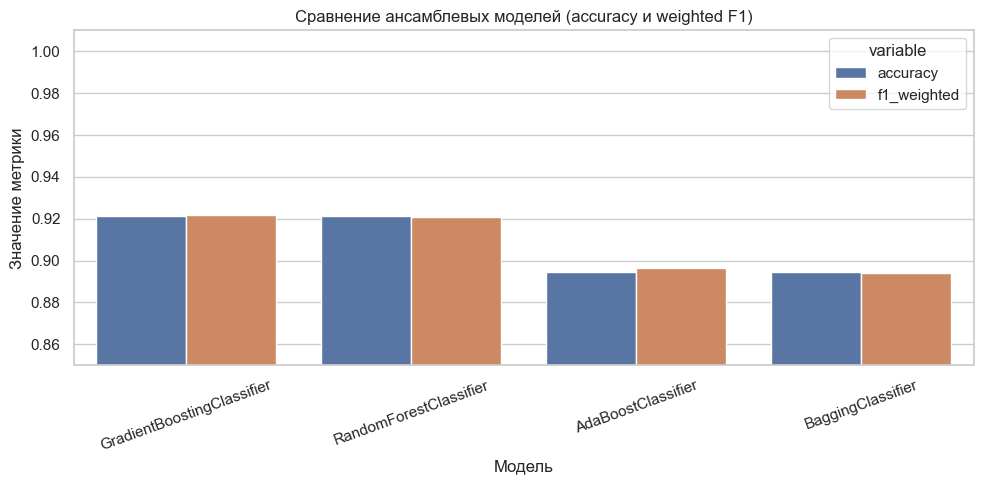

График сохранен: D:\6 сем\тмо\lab5\artifacts\lab5\ensemble_metrics_comparison.png


In [ ]:
# 7. Визуальное сравнение моделей
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=results_df.melt(id_vars="model", value_vars=["accuracy", "f1_weighted"]),
                 x="model", y="value", hue="variable")
ax.set_title("Сравнение ансамблевых моделей (accuracy и weighted F1)")
ax.set_xlabel("Модель")
ax.set_ylabel("Значение метрики")
plt.xticks(rotation=20)
plt.ylim(0.85, 1.01)
plt.tight_layout()

plot_path = artifacts_dir / "ensemble_metrics_comparison.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print("График сохранен:", plot_path)

In [ ]:
# 8. Сохранение табличных результатов
metrics_csv_path = artifacts_dir / "ensemble_models_metrics.csv"
summary_json_path = artifacts_dir / "summary.json"

results_df.to_csv(metrics_csv_path, index=False)

summary = {
    "dataset": "sklearn Iris (с добавленным категориальным признаком)",
    "task_type": "classification",
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "best_model_on_test": {
        "model": best_model_name,
        "accuracy": float(results_df.loc[0, "accuracy"]),
        "f1_weighted": float(results_df.loc[0, "f1_weighted"]),
    },
    "models_test_metrics": results_df.to_dict(orient="records"),
}

import json
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Сохранено:")
print("-", metrics_csv_path)
print("-", summary_json_path)

Сохранено:
- D:\6 сем\тмо\lab5\artifacts\lab5\ensemble_models_metrics.csv
- D:\6 сем\тмо\lab5\artifacts\lab5\summary.json


# Вывод

В работе обучены и сравнены 4 ансамблевые модели:
- BaggingClassifier;
- RandomForestClassifier;
- AdaBoostClassifier;
- GradientBoostingClassifier.

По метрикам `accuracy` и `weighted F1` на тестовой выборке получено сопоставление качества моделей, определена лучшая модель.

Требования задания выполнены: проведена обработка пропусков, выполнено кодирование категориальных признаков, использован `train_test_split`, выполнено обучение и сравнение ансамблей.